In [1]:
import pandas as pd, numpy as np, holidays, warnings, joblib
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, silhouette_score
from sklearn.inspection import permutation_importance
from scipy.stats import skew
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split ,KFold
warnings.filterwarnings('ignore')

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
df_grammy_raw=pd.read_csv("/content/Copy of Grammy_IG_posts_v2.csv", sep=';')
df_analytic_raw=pd.read_csv("/content/Copy of Instagram_Analytics.csv")

In [4]:
df_grammy_raw.head(10)

,Unnamed: 0,post_time,user,gender,followers,awards,day_difference,video,likes,comments,carousel,post_images,length_caption,number_hashtags,publication_weekday,IM_performance
0,0,2023-02-08_17-50-24_UTC,user001,F,12721,1,362,0,275,7,0,1,511,0,Wednesday,Offstage
1,1,2023-02-13_13-28-32_UTC,user001,F,12721,1,357,1,670,15,0,1,454,1,Monday,Backstage
2,2,2023-02-14_11-14-32_UTC,user001,F,12721,1,356,1,785,12,0,1,389,9,Tuesday,Offstage
3,3,2023-02-27_15-06-37_UTC,user001,F,12721,1,343,0,472,7,1,5,417,1,Monday,Backstage
4,4,2023-03-06_13-00-09_UTC,user001,F,12721,1,336,0,304,7,0,1,840,0,Monday,Backstage
5,5,2023-03-09_13-40-50_UTC,user001,F,12721,1,333,0,1704,88,1,3,740,1,Thursday,Backstage
6,6,2023-03-17_19-48-12_UTC,user001,F,12721,1,325,0,1620,72,1,10,588,1,Friday,Frontstage
7,7,2023-03-21_13-32-25_UTC,user001,F,12721,1,321,0,2759,146,1,10,2103,1,Tuesday,Backstage
8,8,2023-03-25_18-31-17_UTC,user001,F,12721,1,317,0,547,7,1,5,1372,1,Saturday,Backstage
9,9,2023-03-29_19-26-49_UTC,user001,F,12721,1,313,0,445,4,1,5,486,1,Wednesday,Frontstage


In [5]:
df_grammy_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34811 entries, 0 to 34810
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           34811 non-null  int64 
 1   post_time            34811 non-null  object
 2   user                 34811 non-null  object
 3   gender               34811 non-null  object
 4   followers            34811 non-null  int64 
 5   awards               34811 non-null  int64 
 6   day_difference       34811 non-null  int64 
 7   video                34811 non-null  int64 
 8   likes                34811 non-null  int64 
 9   comments             34811 non-null  int64 
 10  carousel             34811 non-null  int64 
 11  post_images          34811 non-null  int64 
 12  length_caption       34811 non-null  int64 
 13  number_hashtags      34811 non-null  int64 
 14  publication_weekday  34811 non-null  object
 15  IM_performance       34811 non-null  object
dtypes: i

In [6]:
df_grammy_raw.describe()

,Unnamed: 0,followers,awards,day_difference,video,likes,comments,carousel,post_images,length_caption,number_hashtags
count,34811.000000,3.481100e+04,34811.000000,34811.000000,34811.000000,3.481100e+04,34811.000000,34811.000000,34811.000000,34811.000000,34811.000000
mean,17405.000000,1.062406e+07,1.509580,184.289391,0.436586,1.409605e+05,877.973141,0.259171,2.096378,249.427738,2.192008
std,10049.214447,3.767269e+07,1.144307,104.299060,0.495970,6.380424e+05,4551.318844,0.438186,2.392219,296.846651,3.501732
min,0.000000,7.120000e+02,1.000000,1.000000,0.000000,1.000000e+00,0.000000,0.000000,1.000000,0.000000,0.000000
25%,8702.500000,6.599900e+04,1.000000,95.000000,0.000000,5.440000e+02,13.000000,0.000000,1.000000,73.000000,1.000000
50%,17405.000000,5.524280e+05,1.000000,184.000000,0.000000,4.319000e+03,69.000000,0.000000,1.000000,156.000000,1.000000
75%,26107.500000,2.998286e+06,2.000000,274.000000,1.000000,2.659400e+04,294.000000,1.000000,2.000000,307.500000,2.000000
max,34810.000000,3.804718e+08,9.000000,364.000000,1.000000,1.290995e+07,223272.000000,1.000000,10.000000,2206.000000,30.000000


In [7]:
df_grammy_raw.duplicated().sum()

np.int64(0)

In [8]:
for col in df_grammy_raw.columns:
  print(col)
  print(f"{df_grammy_raw[col].unique()} \n number of unique {df_grammy_raw[col].nunique()}",)
  print('--'*50)

Unnamed: 0
[    0     1     2 ... 34808 34809 34810] 
 number of unique 34811
----------------------------------------------------------------------------------------------------
post_time
['2023-02-08_17-50-24_UTC' '2023-02-13_13-28-32_UTC'
 '2023-02-14_11-14-32_UTC' ... '2024-01-04_19-02-35_UTC'
 '2024-01-26_12-02-16_UTC' '2024-02-03_21-37-34_UTC'] 
 number of unique 34650
----------------------------------------------------------------------------------------------------
user
['user001' 'user002' 'user003' 'user004' 'user005' 'user006' 'user007'
 'user008' 'user009' 'user010' 'user011' 'user012' 'user013' 'user014'
 'user015' 'user016' 'user017' 'user018' 'user019' 'user020' 'user021'
 'user022' 'user023' 'user024' 'user025' 'user026' 'user027' 'user028'
 'user029' 'user030' 'user031' 'user032' 'user033' 'user034' 'user035'
 'user036' 'user037' 'user038' 'user039' 'user040' 'user041' 'user042'
 'user043' 'user044' 'user045' 'user046' 'user047' 'user048' 'user049'
 'user050' 'user051

In [9]:
df_analytic_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   post_id                   29999 non-null  object 
 1   account_id                29999 non-null  int64  
 2   account_type              29999 non-null  object 
 3   follower_count            29999 non-null  int64  
 4   media_type                29999 non-null  object 
 5   content_category          29999 non-null  object 
 6   traffic_source            29999 non-null  object 
 7   has_call_to_action        29999 non-null  int64  
 8   post_datetime             29999 non-null  object 
 9   post_date                 29999 non-null  object 
 10  post_hour                 29999 non-null  int64  
 11  day_of_week               29999 non-null  object 
 12  likes                     29999 non-null  int64  
 13  comments                  29999 non-null  int64  
 14  shares

In [10]:
df_analytic_raw.describe()

,account_id,follower_count,has_call_to_action,post_hour,likes,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count
count,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000
mean,10.567819,10278.305477,0.348778,11.499417,287.653588,8.521917,14.426614,42.517284,6272.475449,8466.952498,0.042107,502.152805,120.081169,7.987933
std,5.763952,6691.862669,0.476592,6.900587,317.647682,10.116505,16.420899,47.808844,4985.877059,6825.900355,0.024095,290.364038,11.009108,2.828130
min,1.000000,3083.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,268.000000,327.000000,0.000000,0.000000,70.000000,0.000000
25%,6.000000,5824.000000,0.000000,6.000000,104.000000,3.000000,5.000000,15.000000,3058.000000,4102.000000,0.024000,251.000000,113.000000,6.000000
50%,11.000000,9044.000000,0.000000,12.000000,199.000000,6.000000,10.000000,29.000000,4913.000000,6595.000000,0.040600,501.000000,120.000000,8.000000
75%,16.000000,10739.000000,1.000000,17.000000,363.000000,11.000000,19.000000,54.000000,7863.000000,10620.500000,0.057000,755.000000,127.000000,10.000000
max,20.000000,31095.000000,1.000000,23.000000,10632.000000,339.000000,516.000000,1542.000000,73339.000000,105203.000000,0.271000,1000.000000,166.000000,21.000000


In [11]:
df_analytic_raw.duplicated().sum()

np.int64(0)

In [12]:
for col in df_analytic_raw.columns:
  print(col)
  print(f"{df_analytic_raw[col].unique()} \n number of unique {df_analytic_raw[col].nunique()}",)
  print('--'*50)

post_id
['IG0000001' 'IG0000002' 'IG0000003' ... 'IG0029997' 'IG0029998'
 'IG0029999'] 
 number of unique 29999
----------------------------------------------------------------------------------------------------
account_id
[ 7 20 15 11  8 19  4  3  2 12  6  1 17 10 16  5  9 18 14 13] 
 number of unique 20
----------------------------------------------------------------------------------------------------
account_type
['brand' 'creator'] 
 number of unique 2
----------------------------------------------------------------------------------------------------
follower_count
[ 3551 31095  8167  9044 15986  3447  4972 10018 22291 13798 10034  9461
 15923  4542  9696 10739  6916  7486  3083  5824] 
 number of unique 20
----------------------------------------------------------------------------------------------------
media_type
['reel' 'image' 'carousel'] 
 number of unique 3
----------------------------------------------------------------------------------------------------
content_catego

In [13]:
df_grammy_raw['post_time']=pd.to_datetime(df_grammy_raw['post_time'], format='%Y-%m-%d_%H-%M-%S_UTC')
df_grammy_raw['Engagement']=(df_grammy_raw['likes']+df_grammy_raw['comments'])
df_analytic_raw['post_datetime']=pd.to_datetime(df_analytic_raw['post_datetime'], format='%Y-%m-%d %H:%M:%S')
df_analytic_raw['Engagement']=(df_analytic_raw['likes']+df_analytic_raw['comments']+df_analytic_raw['shares']+df_analytic_raw['saves'])
print(f"grammy {df_grammy_raw.shape} analytic {df_analytic_raw.shape} combined {len(df_grammy_raw)+len(df_analytic_raw)}")

grammy (34811, 17) analytic (29999, 24) combined 64810


In [14]:
def bucket(h):
    if h in [6,7,8,11,12,19,20]: return "peak"
    elif h in [23,0,1,2,3,4,5]: return "low"
    else: return "normal"

In [15]:
def add_features_grammy(df):
    df=df.copy()
    df['post_date']=df['post_time'].dt.date
    years=range(df['post_time'].dt.year.min(), df['post_time'].dt.year.max()+1)
    ch=holidays.US(years=years)
    df['is_holiday']=df['post_date'].isin(ch)
    df['hour']=df['post_time'].dt.hour
    df['reach_time_bucket']=df['hour'].apply(bucket)
    df=df.sort_values(['user','post_time'])
    df['user_post_count']=df.groupby('user').cumcount()
    df['user_median_engagement']=df.groupby('user')['Engagement'].transform(lambda x: x.expanding().median().shift(1)).fillna(0)
    df['hashtag_bucket']=pd.cut(df['number_hashtags'], bins=[-1,0,5,15,30], labels=['none','low','medium','high'])
    df['caption_length_bucket']=pd.cut(df['length_caption'], bins=[-1,50,150,300,10000], labels=['short','medium','long','very_long'])
    df['is_weekend']=df['publication_weekday'].isin(['Saturday','Sunday']).astype(int)
    df.drop(columns=['post_time','user','post_date','hour','likes','comments','Unnamed: 0','awards','day_difference','IM_performance'], inplace=True)
    return df


In [16]:
def add_features_analytic(df):
    df=df.copy()
    df['post_date']=df['post_datetime'].dt.date
    years=range(df['post_datetime'].dt.year.min(), df['post_datetime'].dt.year.max()+1)
    ch=holidays.US(years=years)
    df['is_holiday']=df['post_date'].isin(ch)
    df['hour']=df['post_datetime'].dt.hour
    df['reach_time_bucket']=df['hour'].apply(bucket)
    df=df.sort_values(['account_id','post_datetime'])
    df['user_post_count']=df.groupby('account_id').cumcount()
    df['user_median_engagement']=df.groupby('account_id')['Engagement'].transform(lambda x: x.expanding().median().shift(1)).fillna(0)
    df['hashtag_bucket']=pd.cut(df['hashtags_count'], bins=[-1,0,5,15,30], labels=['none','low','medium','high'])
    df['caption_length_bucket']=pd.cut(df['caption_length'], bins=[-1,50,150,300,10000], labels=['short','medium','long','very_long'])
    df['is_weekend']=df['day_of_week'].isin(['Saturday','Sunday']).astype(int)
    df['post_images']=(df['media_type']=='image').astype(np.int16)
    df['carousel']=(df['media_type']=='carousel').astype(np.int16)
    df['video']=(df['media_type']=='reel').astype(np.int16)
    df.drop(columns=['media_type'], inplace=True)
    df['publication_weekday']=df['day_of_week']
    df['number_hashtags']=df['hashtags_count']
    df['followers']=df['follower_count']
    df['length_caption']=df['caption_length']
    df.drop(columns=['day_of_week','hashtags_count','follower_count','caption_length'], inplace=True)
    df.drop(columns=['post_datetime','account_id','post_date','hour','likes','comments','shares','saves','post_id','account_type','content_category','traffic_source','has_call_to_action','post_hour','reach','impressions','engagement_rate','followers_gained','performance_bucket_label'], errors='ignore')
    return df

In [17]:
df_grammy_fe = add_features_grammy(df_grammy_raw)
df_analytic_fe = add_features_analytic(df_analytic_raw)
df_grammy_fe.shape, df_analytic_fe.shape

((34811, 16), (29999, 34))

In [18]:
common = list(set(df_grammy_fe.columns) & set(df_analytic_fe.columns))
print("common", common)
df = pd.concat([df_grammy_fe[common], df_analytic_fe[common]], ignore_index=True)
df.shape

common ['length_caption', 'user_post_count', 'user_median_engagement', 'carousel', 'followers', 'post_images', 'hashtag_bucket', 'caption_length_bucket', 'number_hashtags', 'is_weekend', 'video', 'publication_weekday', 'Engagement', 'is_holiday', 'reach_time_bucket']


(64810, 15)

In [19]:
catcol=['video','carousel','publication_weekday','caption_length_bucket','hashtag_bucket','reach_time_bucket','is_weekend','is_holiday']
numcol=[c for c in df.columns if c not in catcol]

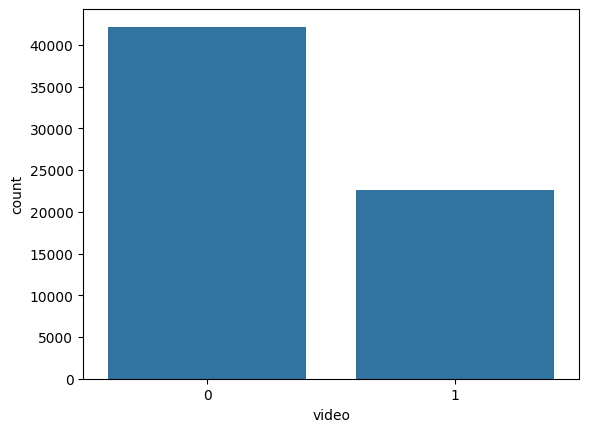

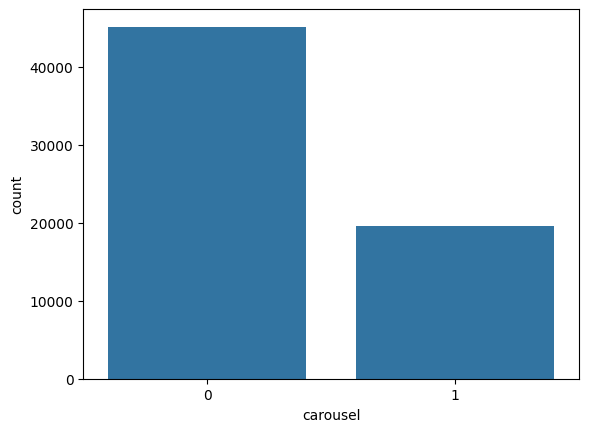

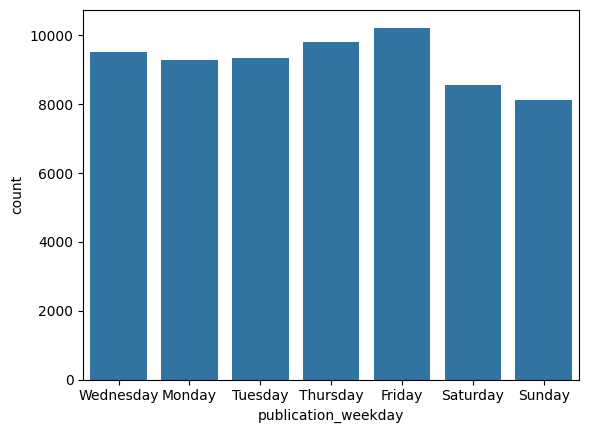

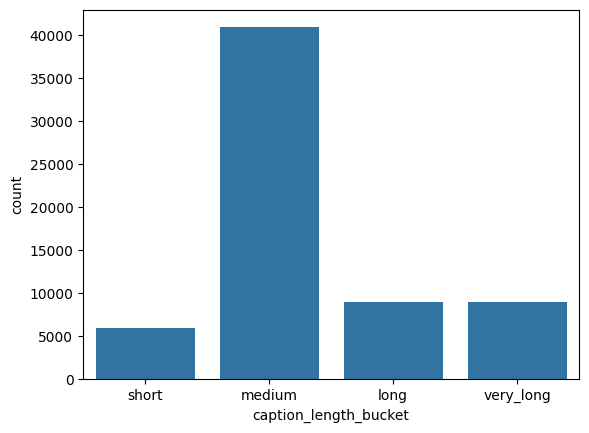

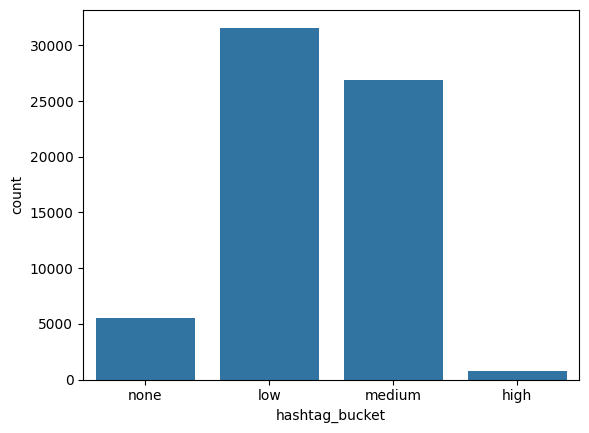

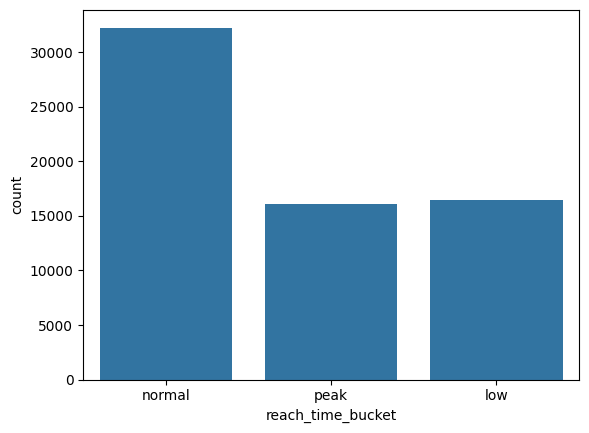

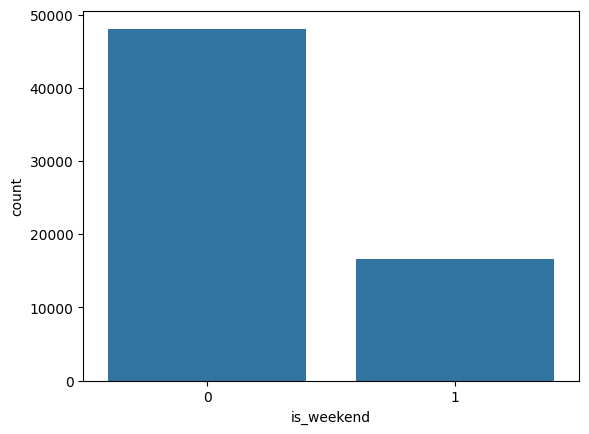

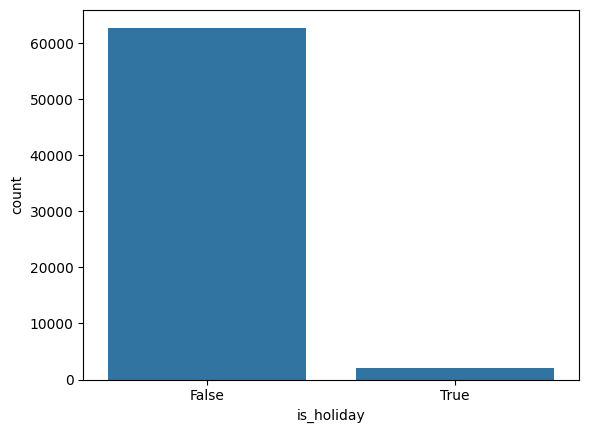

In [20]:
for col in catcol:
  sns.countplot(x=col,data=df)
  plt.show()

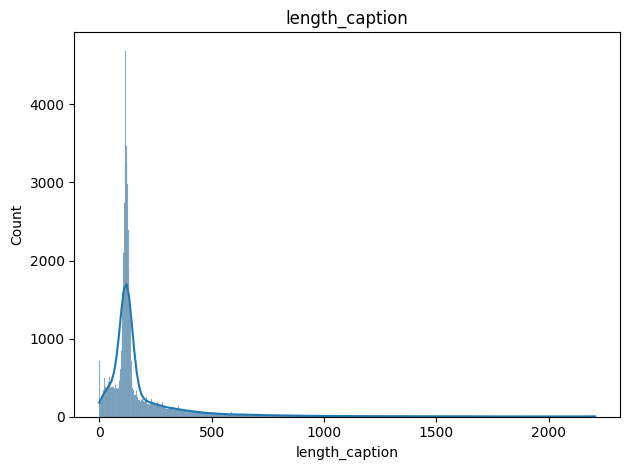

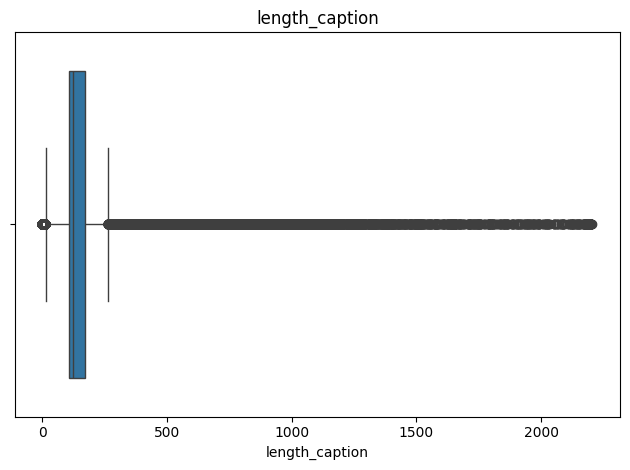

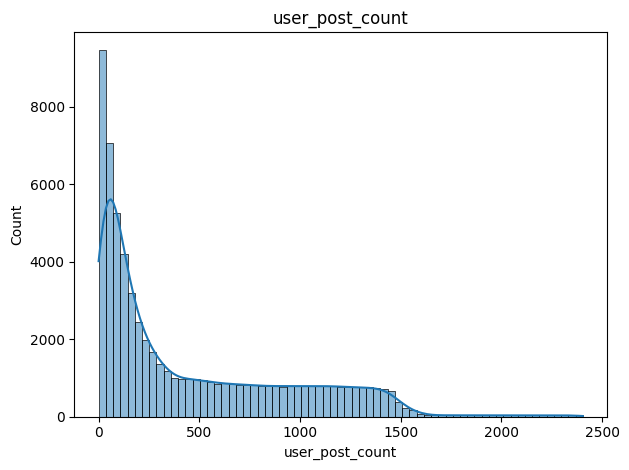

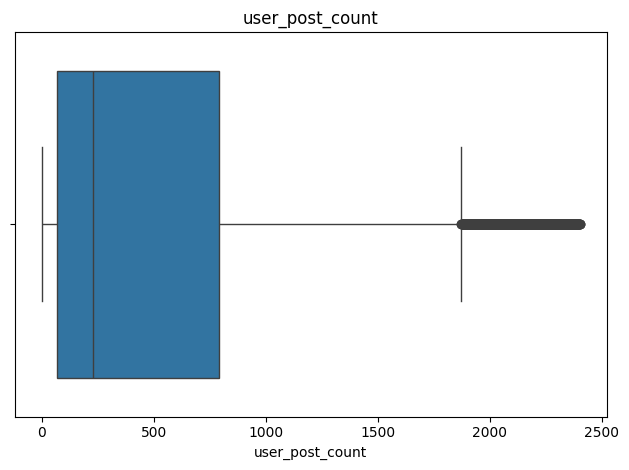

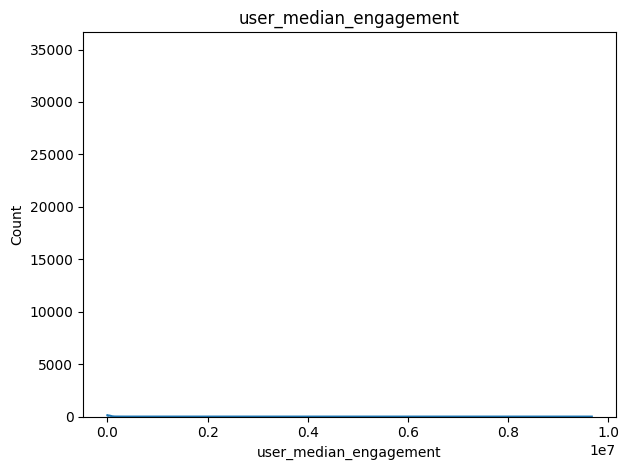

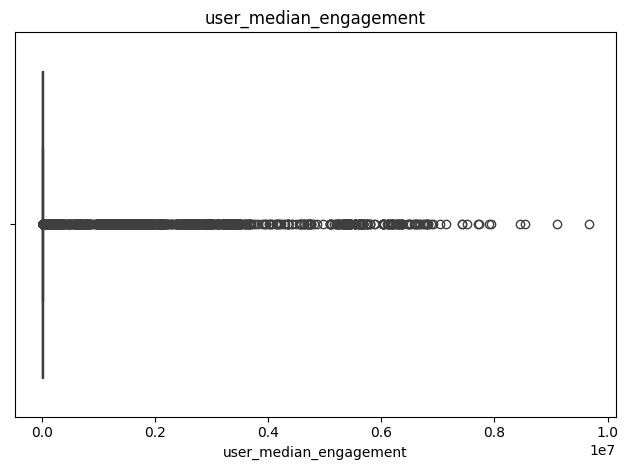

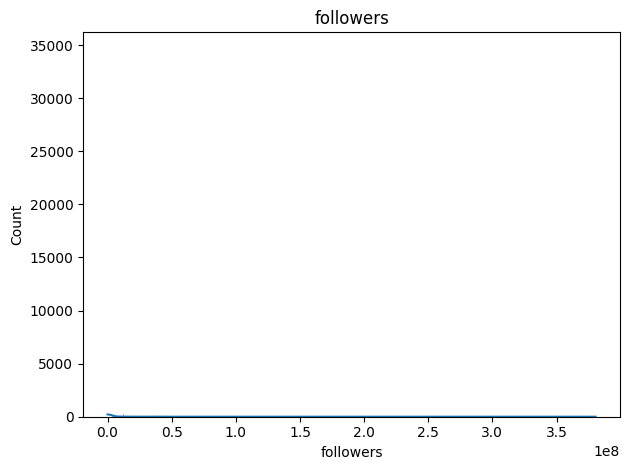

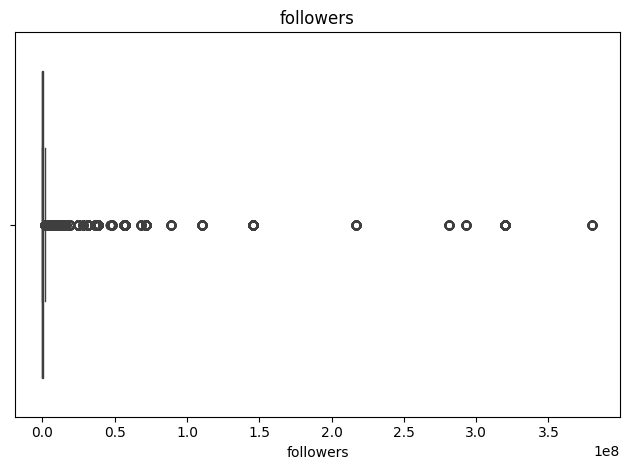

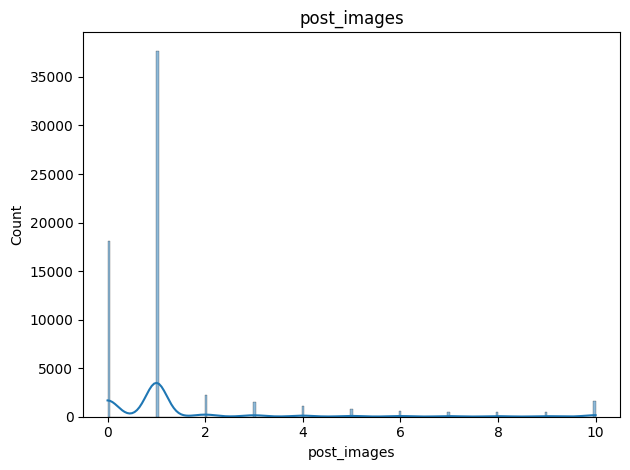

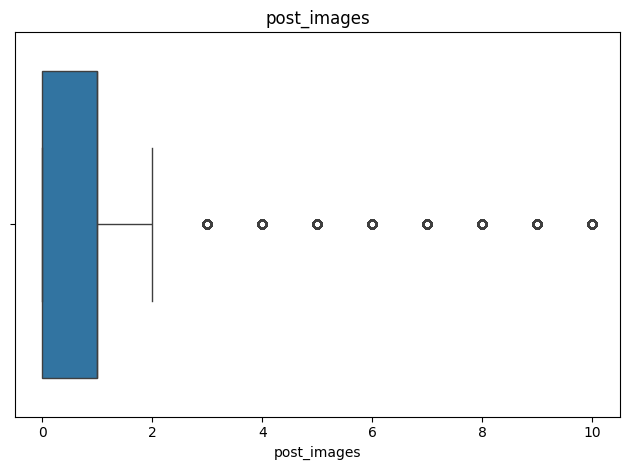

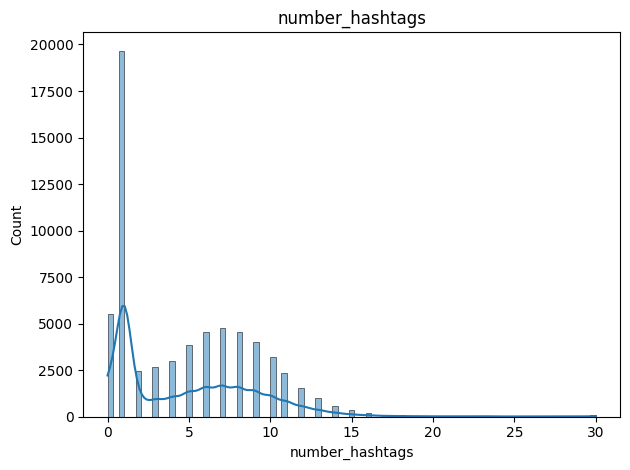

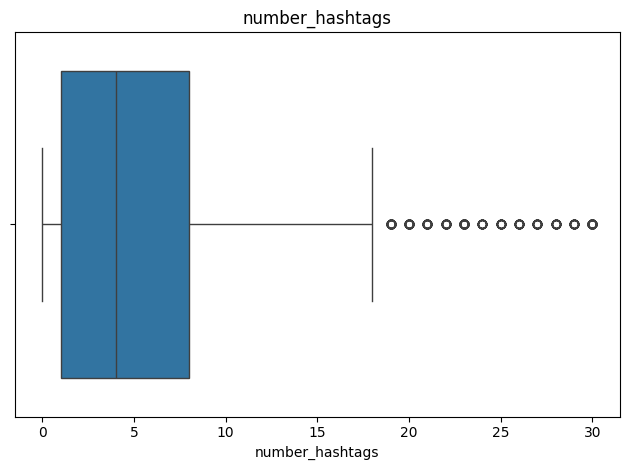

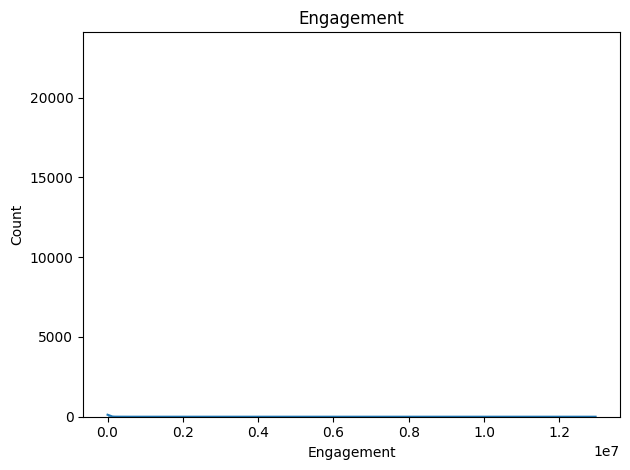

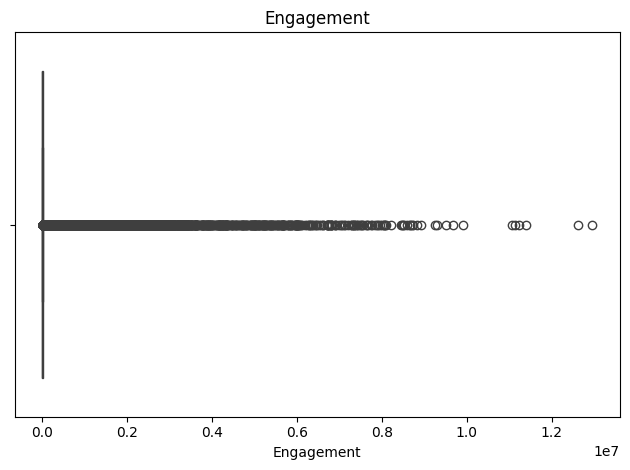

In [21]:
for col in numcol:
  sns.histplot(data=df , x =col , kde=True)
  plt.title(col)
  plt.tight_layout()
  plt.show()

  sns.boxplot(data=df, x=col)
  plt.title(col)
  plt.tight_layout()
  plt.show()

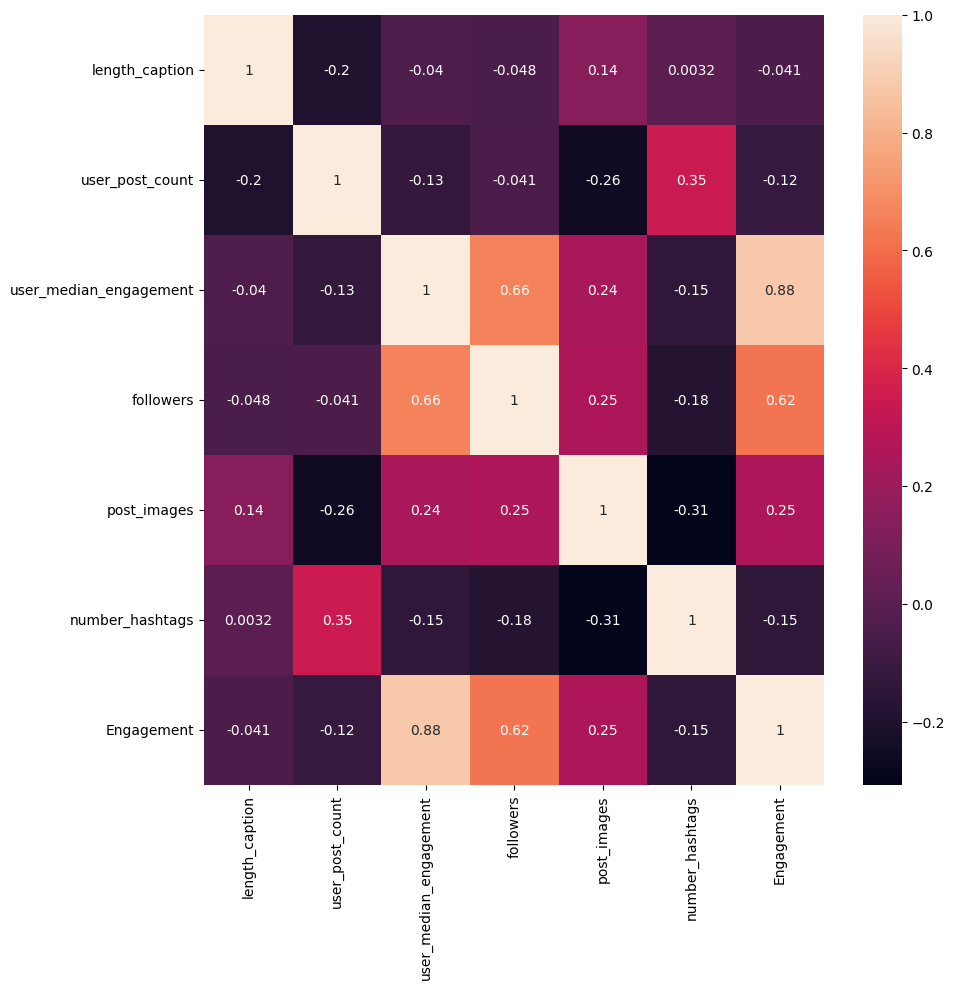

In [22]:
plt.figure(figsize=(10,10))
sns.heatmap(df[numcol].corr(),annot=True)
plt.show()

In [23]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df.shape,test_df.shape

((51848, 15), (12962, 15))

In [24]:
catcol=['video','carousel','publication_weekday','caption_length_bucket','hashtag_bucket','reach_time_bucket','is_weekend','is_holiday']
numcol=[c for c in train_df.columns if c not in catcol]
print("catcol", catcol)
print("numcol", [c for c in numcol if c!='Engagement'])

catcol ['video', 'carousel', 'publication_weekday', 'caption_length_bucket', 'hashtag_bucket', 'reach_time_bucket', 'is_weekend', 'is_holiday']
numcol ['length_caption', 'user_post_count', 'user_median_engagement', 'followers', 'post_images', 'number_hashtags']


In [25]:
train_processed=train_df.copy()
test_processed=test_df.copy()

In [26]:
for col in [c for c in numcol if c!='Engagement']:
    test_processed['log'+col]=np.log1p(test_processed[col])
    train_processed['log'+col]=np.log1p(train_processed[col])
    test_processed.drop(columns=col, inplace=True)
    train_processed.drop(columns=col, inplace=True)

In [27]:
train_processed=pd.get_dummies(train_processed, columns=catcol, prefix=catcol, drop_first=True).astype(float)
test_processed=pd.get_dummies(test_processed, columns=catcol, prefix=catcol, drop_first=True).astype(float)

In [28]:
X_train=train_processed.drop('Engagement',axis=1)
y_train_raw=train_processed['Engagement']
X_test=test_processed.drop('Engagement',axis=1)
y_test_raw=test_processed['Engagement']
X_train.shape, X_test.shape,X_train.columns

((51848, 24),
 (12962, 24),
 Index(['loglength_caption', 'loguser_post_count', 'loguser_median_engagement',
        'logfollowers', 'logpost_images', 'lognumber_hashtags', 'video_1',
        'carousel_1', 'publication_weekday_Monday',
        'publication_weekday_Saturday', 'publication_weekday_Sunday',
        'publication_weekday_Thursday', 'publication_weekday_Tuesday',
        'publication_weekday_Wednesday', 'caption_length_bucket_medium',
        'caption_length_bucket_long', 'caption_length_bucket_very_long',
        'hashtag_bucket_low', 'hashtag_bucket_medium', 'hashtag_bucket_high',
        'reach_time_bucket_normal', 'reach_time_bucket_peak', 'is_weekend_1',
        'is_holiday_True'],
       dtype='object'))

In [29]:
set_train=set(X_train.columns)
set_test=set(X_test.columns)
set_train.difference(set_test)

set()

In [30]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51848 entries, 61163 to 56422
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   loglength_caption                51848 non-null  float64
 1   loguser_post_count               51848 non-null  float64
 2   loguser_median_engagement        51848 non-null  float64
 3   logfollowers                     51848 non-null  float64
 4   logpost_images                   51848 non-null  float64
 5   lognumber_hashtags               51848 non-null  float64
 6   video_1                          51848 non-null  float64
 7   carousel_1                       51848 non-null  float64
 8   publication_weekday_Monday       51848 non-null  float64
 9   publication_weekday_Saturday     51848 non-null  float64
 10  publication_weekday_Sunday       51848 non-null  float64
 11  publication_weekday_Thursday     51848 non-null  float64
 12  publication_weekday

In [31]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12962 entries, 17746 to 1444
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   loglength_caption                12962 non-null  float64
 1   loguser_post_count               12962 non-null  float64
 2   loguser_median_engagement        12962 non-null  float64
 3   logfollowers                     12962 non-null  float64
 4   logpost_images                   12962 non-null  float64
 5   lognumber_hashtags               12962 non-null  float64
 6   video_1                          12962 non-null  float64
 7   carousel_1                       12962 non-null  float64
 8   publication_weekday_Monday       12962 non-null  float64
 9   publication_weekday_Saturday     12962 non-null  float64
 10  publication_weekday_Sunday       12962 non-null  float64
 11  publication_weekday_Thursday     12962 non-null  float64
 12  publication_weekday_

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
single = HistGradientBoostingRegressor(max_depth=8, learning_rate=0.08, max_iter=300, random_state=42)
single.fit(X_train_scaled, y_train_raw)
pred_single = single.predict(X_test_scaled)
pred_single_train = single.predict(X_train_scaled)
print(f"SINGLE  test real R2 {r2_score(y_test_raw,pred_single):.4f} RMSE {np.sqrt(mean_squared_error(y_test_raw,pred_single)):.0f}")
print(f"SINGLE  train  real R2 {r2_score(y_train_raw,pred_single_train):.4f} RMSE {np.sqrt(mean_squared_error(y_train_raw,pred_single_train)):.0f}")

SINGLE  test real R2 0.8357 RMSE 202190
SINGLE  train  real R2 0.9063 RMSE 143492


In [34]:
single2 = RandomForestRegressor(
    n_estimators=300,      # analogous to max_iter — number of trees
    max_depth=8,           # same meaning as in HGBR
    random_state=42,
    n_jobs=-1               # use all CPU cores, RF trees are independent so this parallelizes well
)
single2.fit(X_train_scaled, y_train_raw)
pred_single2 = single2.predict(X_test_scaled)
pred_single2_train = single2.predict(X_train_scaled)
print(f"single2  test real R2 {r2_score(y_test_raw,pred_single2):.4f} RMSE {np.sqrt(mean_squared_error(y_test_raw,pred_single2)):.0f}")
print(f"single2  train  real R2 {r2_score(y_train_raw,pred_single2_train):.4f} RMSE {np.sqrt(mean_squared_error(y_train_raw,pred_single2_train)):.0f}")

single2  test real R2 0.8663 RMSE 182407
single2  train  real R2 0.9188 RMSE 133627


In [35]:
def evaluate_cv(X, y_raw, n_splits=5, **hgbr_params):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    r2_raws, rmses =  [], []

    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr_raw, y_val_raw = y_raw.iloc[train_idx], y_raw.iloc[val_idx]

        m = HistGradientBoostingRegressor(random_state=42, **hgbr_params)
        m.fit(X_tr, y_tr_raw)
        pred_raw = m.predict(X_val)


        r2_raws.append(r2_score(y_val_raw, pred_raw))
        rmses.append(np.sqrt(mean_squared_error(y_val_raw, pred_raw)))

    print(f"R2_raw: {np.mean(r2_raws):.4f} ± {np.std(r2_raws):.4f}")
    print(f"RMSE_raw: {np.mean(rmses):.0f} ± {np.std(rmses):.0f}")
    return r2_raws, rmses

X_full = pd.concat([X_train, X_test], ignore_index=True)
y_full_raw = pd.concat([y_train_raw, y_test_raw], ignore_index=True)

evaluate_cv(X_full,y_full_raw, max_depth=8, learning_rate=0.08, max_iter=300)

R2_raw: 0.8267 ± 0.0165
RMSE_raw: 197467 ± 13470


([0.8393142972481982,
  0.8495885256520291,
  0.8037004779281434,
  0.8144072211232236,
  0.8265458435700287],
 [np.float64(186849.4558394901),
  np.float64(187149.79029153768),
  np.float64(223060.19298636657),
  np.float64(198467.3453420833),
  np.float64(191810.17754444628)])

In [36]:
def evaluate_cv_rf(X, y_raw, n_splits=5, **rf_params):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    r2_raws, rmses = [], []

    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr_raw, y_val_raw = y_raw.iloc[train_idx], y_raw.iloc[val_idx]

        m = RandomForestRegressor(random_state=42, n_jobs=-1, **rf_params)
        m.fit(X_tr, y_tr_raw)
        pred_raw = m.predict(X_val)

        r2_raws.append(r2_score(y_val_raw, pred_raw))
        rmses.append(np.sqrt(mean_squared_error(y_val_raw, pred_raw)))

    print(f"RF R2_raw: {np.mean(r2_raws):.4f} ± {np.std(r2_raws):.4f}")
    print(f"RF RMSE_raw: {np.mean(rmses):.0f} ± {np.std(rmses):.0f}")
    return r2_raws, rmses

X_full = pd.concat([X_train, X_test], ignore_index=True)
y_full_raw = pd.concat([y_train_raw, y_test_raw], ignore_index=True)

evaluate_cv_rf(X_full, y_full_raw, n_estimators=300, max_depth=8)

RF R2_raw: 0.8342 ± 0.0120
RF RMSE_raw: 193256 ± 12164


([0.8442986553223859,
  0.8474648978964965,
  0.8138367569476325,
  0.8295658589102621,
  0.8360655565025746],
 [np.float64(183928.65743692702),
  np.float64(188466.32374423606),
  np.float64(217224.8072194521),
  np.float64(190189.62477156508),
  np.float64(186472.32986225287)])

In [37]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
train_cluster = kmeans.fit_predict(X_train_scaled)
test_cluster = kmeans.predict(X_test_scaled)
print(f"KMeans k=3 train {pd.Series(train_cluster).value_counts().sort_index().to_string()}")
print(f"KMeans k=3 test {pd.Series(test_cluster).value_counts().sort_index().to_string()}")
print(f"silhouette train {silhouette_score(X_train_scaled, train_cluster):.3f}")

desc = pd.DataFrame(train_df).assign(cluster=train_cluster).groupby('cluster')['Engagement'].describe()
print(desc.to_string())

cluster_means = pd.Series(y_train_raw.values).groupby(train_cluster).mean()
print("cluster means (raw engagement):")
print(cluster_means.sort_values())

ranked = cluster_means.sort_values().index.tolist()  # [low_id, mid_id, high_id]
label_map = {ranked[0]: 'Low', ranked[1]: 'Mid', ranked[2]: 'High'}
print("derived label_map:", label_map)

print(desc.rename(index=lambda c: f"{c}_{label_map[c]}").to_string())

KMeans k=3 train 0    20067
1    24604
2     7177
KMeans k=3 test 0    5005
1    6170
2    1787
silhouette train 0.180
           count           mean            std  min     25%     50%      75%         max
cluster                                                                                 
0        20067.0  167425.310310  667238.936987  1.0  1103.0  7480.0  38252.0  12962636.0
1        24604.0     411.416558    1931.181606  0.0   126.0   242.0    449.0    139218.0
2         7177.0   72729.051972  547901.113697  2.0   220.0  1159.0   8628.0  12617055.0
cluster means (raw engagement):
1       411.416558
2     72729.051972
0    167425.310310
dtype: float64
derived label_map: {1: 'Low', 2: 'Mid', 0: 'High'}
           count           mean            std  min     25%     50%      75%         max
cluster                                                                                 
0_High   20067.0  167425.310310  667238.936987  1.0  1103.0  7480.0  38252.0  12962636.0
1_Low    24604

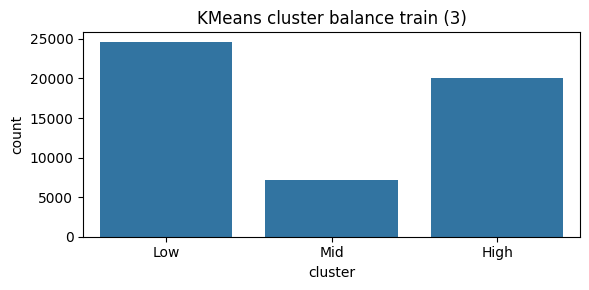

In [38]:
train_cluster_labeled = pd.Series(train_cluster).map(label_map).astype(pd.CategoricalDtype(categories=['Low','Mid','High'], ordered=True))

plt.figure(figsize=(6,3))
sns.countplot(x=train_cluster_labeled, order=['Low','Mid','High'])
plt.title("KMeans cluster balance train (3)")
plt.xlabel("cluster"); plt.tight_layout(); plt.show()

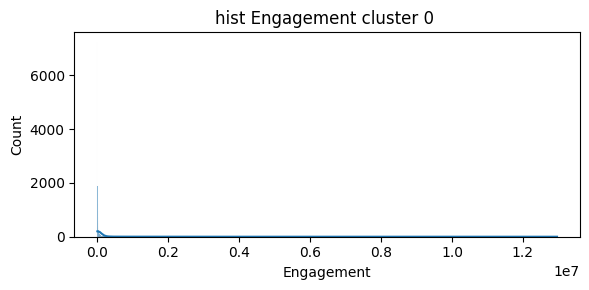

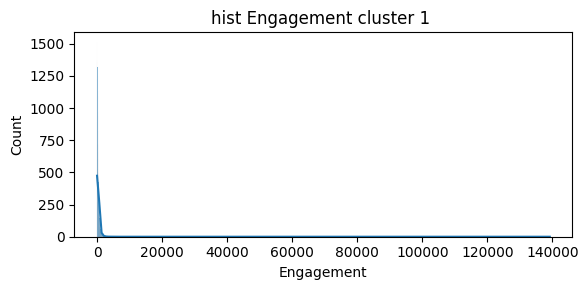

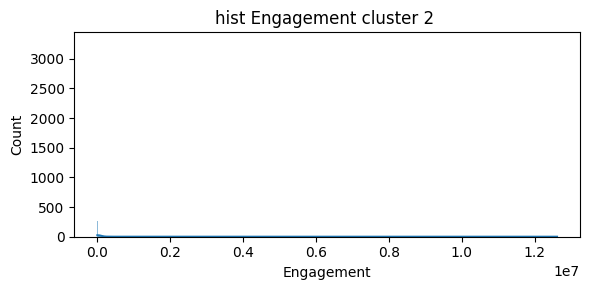

In [39]:
for c in sorted(set(train_cluster)):
    plt.figure(figsize=(6,3))
    sns.histplot(data=pd.DataFrame(train_df).assign(cluster=train_cluster)[lambda d: d['cluster']==c], x='Engagement', kde=True)
    plt.title(f"hist Engagement cluster {c} ")
    plt.tight_layout(); plt.show()

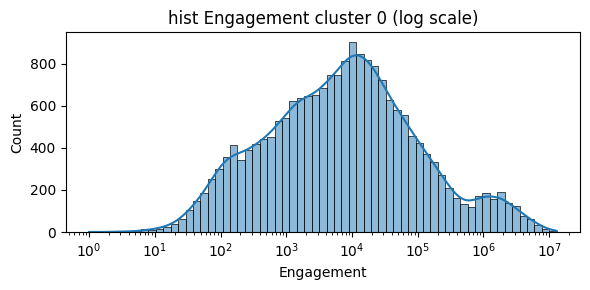

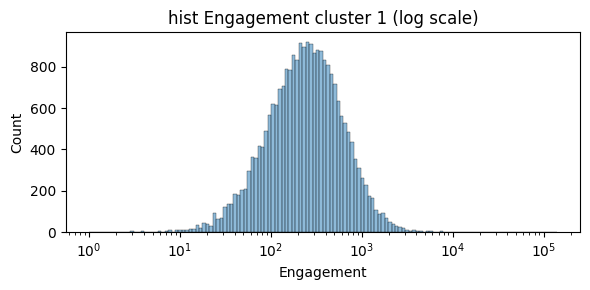

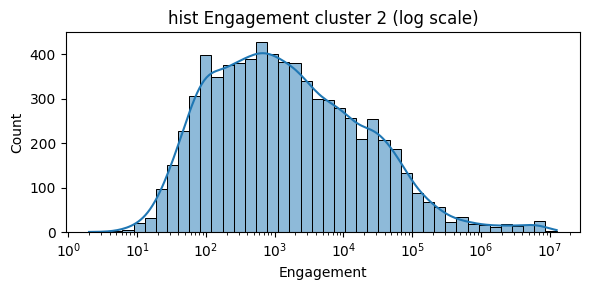

In [40]:
for c in sorted(set(train_cluster)):
    plt.figure(figsize=(6,3))
    sns.histplot(data=pd.DataFrame(train_df).assign(cluster=train_cluster)[lambda d: d['cluster']==c], x='Engagement', kde=True,log_scale=True)
    plt.title(f"hist Engagement cluster {c} (log scale)")
    plt.tight_layout(); plt.show()

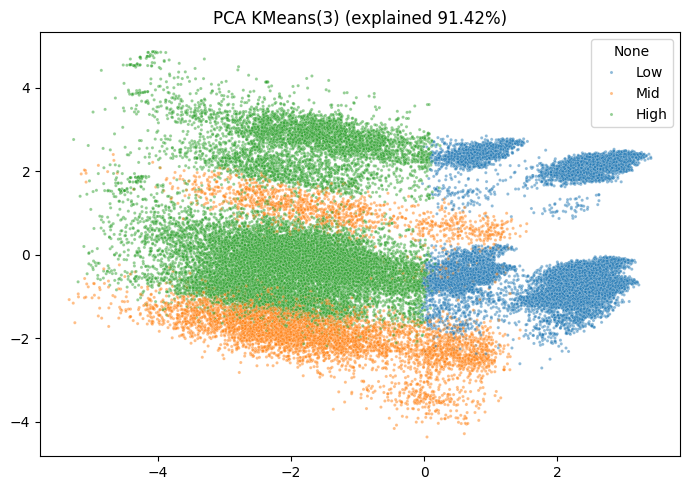

In [41]:
pca = PCA(n_components=15)
X_pca = pca.fit_transform(X_train_scaled)
plt.figure(figsize=(7,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=train_cluster_labeled, palette='tab10', s=5, alpha=0.5)
plt.title(f"PCA KMeans(3) (explained {pca.explained_variance_ratio_.sum():.2%})")
plt.tight_layout(); plt.show()

In [42]:
experts={}
for c in range(3):
    mask = train_cluster==c
    Xc=X_train[mask]
    yc=y_train_raw[mask]
    print(f"cluster {c} n={mask.sum()} mean_raw {np.expm1(yc).mean():.0f} median {np.median(yc):.0f}")
    m=HistGradientBoostingRegressor(max_depth=8 if mask.sum()>1000 else 6, learning_rate=0.08, max_iter=300, random_state=42)
    m.fit(Xc, yc)
    experts[c]=m
    print(f" cluster {c} train R2 {r2_score(yc, m.predict(Xc)):.4f}")
pred_raw_routed=np.zeros(len(X_test))
for i,c in enumerate(test_cluster):
    m=experts[c]
    pred_raw_routed[i]=m.predict(X_test.iloc[i:i+1])[0]

print(f"MoE k=3 ROUTED test real R2 {r2_score(y_test_raw,pred_raw_routed):.4f} RMSE {np.sqrt(mean_squared_error(y_test_raw,pred_raw_routed)):.0f} MAE {mean_absolute_error(y_test_raw,pred_raw_routed):.0f}")
for c in range(3):
    mask=test_cluster==c
    print(f" cluster {c} test n={mask.sum()} R2_raw {r2_score(y_test_raw[mask], pred_raw_routed[mask]):.4f} RMSE {np.sqrt(mean_squared_error(y_test_raw[mask], pred_raw_routed[mask])):.0f}")
print(f"Single real R2 {r2_score(y_test_raw,pred_single):.4f}")


cluster 0 n=20067 mean_raw inf median 7480
 cluster 0 train R2 0.8588
cluster 1 n=24604 mean_raw inf median 242
 cluster 1 train R2 0.6327
cluster 2 n=7177 mean_raw inf median 1159
 cluster 2 train R2 0.9728
MoE k=3 ROUTED test real R2 0.8606 RMSE 186229 MAE 32770
 cluster 0 test n=5005 R2_raw 0.8396 RMSE 282081
 cluster 1 test n=6170 R2_raw 0.8309 RMSE 492
 cluster 2 test n=1787 R2_raw 0.9212 RMSE 169421
Single real R2 0.8357
q99 2129672 MoE clipped R2 0.7652 single clipped 0.7499


In [43]:
rows=[]
def add_row(name,  y_raw_true, y_raw_pred):
    rows.append([name,r2_score(y_raw_true, y_raw_pred),
                 mean_squared_error(y_raw_true, y_raw_pred),
                 np.sqrt(mean_squared_error(y_raw_true, y_raw_pred)),
                 mean_absolute_error(y_raw_true, y_raw_pred)])

add_row("Single", y_test_raw, pred_single)
for c in range(3):
    mask = test_cluster==c
    # expert alone on its cluster (same as routed but per cluster)
    add_row(f"Expert {c} n={mask.sum()}",y_test_raw[mask], pred_raw_routed[mask])
add_row("MoE routed", y_test_raw, pred_raw_routed)

df_metrics = pd.DataFrame(rows, columns=["Model","R2_raw","MSE_raw","RMSE_raw","MAE_raw"])
print(df_metrics.to_string(index=False))
df_metrics.to_csv("metrics_7row.csv", index=False)

          Model   R2_raw      MSE_raw      RMSE_raw      MAE_raw
         Single 0.835669 4.088064e+10 202189.605479 33216.030877
Expert 0 n=5005 0.839586 7.956947e+10 282080.609136 73829.599831
Expert 1 n=6170 0.830890 2.425055e+05    492.448476   252.942133
Expert 2 n=1787 0.921166 2.870335e+10 169420.634853 30043.667129
     MoE routed 0.860588 3.468134e+10 186229.278475 32770.084345


In [44]:
from sklearn.ensemble import RandomForestRegressor

experts_rf = {}
for c in range(3):
    mask = train_cluster == c
    Xc = X_train[mask]
    yc = y_train_raw[mask]   # already raw, no expm1 needed
    print(f"cluster {c} n={mask.sum()} mean_raw {yc.mean():.0f} median {yc.median():.0f}")

    m = RandomForestRegressor(
        n_estimators=300,
        max_depth=8 if mask.sum() > 1000 else 6,
        random_state=42,
        n_jobs=-1
    )
    m.fit(Xc, yc)
    experts_rf[c] = m
    print(f" cluster {c} train R2 {r2_score(yc, m.predict(Xc)):.4f}")

# batched prediction instead of row-by-row
pred_raw_routed_rf = np.zeros(len(X_test))
for c in range(3):
    mask = test_cluster == c
    if mask.sum() > 0:
        pred_raw_routed_rf[mask] = experts_rf[c].predict(X_test[mask])

print(f"MoE-RF k=3 ROUTED test real R2 {r2_score(y_test_raw, pred_raw_routed_rf):.4f} "
      f"RMSE {np.sqrt(mean_squared_error(y_test_raw, pred_raw_routed_rf)):.0f} "
      f"MAE {mean_absolute_error(y_test_raw, pred_raw_routed_rf):.0f}")

for c in range(3):
    mask = test_cluster == c
    print(f" cluster {c} test n={mask.sum()} "
          f"R2_raw {r2_score(y_test_raw[mask], pred_raw_routed_rf[mask]):.4f} "
          f"RMSE {np.sqrt(mean_squared_error(y_test_raw[mask], pred_raw_routed_rf[mask])):.0f}")

print(f"Single-RF real R2 {r2_score(y_test_raw, pred_single2):.4f}")


cluster 0 n=20067 mean_raw 167425 median 7480
 cluster 0 train R2 0.9089
cluster 1 n=24604 mean_raw 411 median 242
 cluster 1 train R2 0.8879
cluster 2 n=7177 mean_raw 72729 median 1159
 cluster 2 train R2 0.9789
MoE-RF k=3 ROUTED test real R2 0.8690 RMSE 180508 MAE 30241
 cluster 0 test n=5005 R2_raw 0.8543 RMSE 268870
 cluster 1 test n=6170 R2_raw 0.7498 RMSE 599
 cluster 2 test n=1787 R2_raw 0.9070 RMSE 184036
Single-RF real R2 0.8663


In [45]:
rows_rf = []
def add_row_rf(name, y_raw_true, y_raw_pred):
    rows_rf.append([name, r2_score(y_raw_true, y_raw_pred),
                     mean_squared_error(y_raw_true, y_raw_pred),
                     np.sqrt(mean_squared_error(y_raw_true, y_raw_pred)),
                     mean_absolute_error(y_raw_true, y_raw_pred)])

add_row_rf("Single RF", y_test_raw, pred_single2)

for c in range(3):
    mask = test_cluster == c
    add_row_rf(f"Expert RF {c} n={mask.sum()}", y_test_raw[mask], pred_raw_routed_rf[mask])

add_row_rf("MoE RF routed", y_test_raw, pred_raw_routed_rf)

df_metrics_rf = pd.DataFrame(rows_rf, columns=["Model", "R2_raw", "MSE_raw", "RMSE_raw", "MAE_raw"])
print(df_metrics_rf.to_string(index=False))
df_metrics_rf.to_csv("metrics_7row_rf.csv", index=False)

             Model   R2_raw      MSE_raw      RMSE_raw      MAE_raw
         Single RF 0.866252 3.327241e+10 182407.257809 30391.173088
Expert RF 0 n=5005 0.854260 7.229102e+10 268869.891971 68279.425199
Expert RF 1 n=6170 0.749804 3.587844e+05    598.986111   253.918902
Expert RF 2 n=1787 0.906978 3.386913e+10 184035.669974 27237.356868
     MoE RF routed 0.869023 3.258316e+10 180508.055277 30240.577031


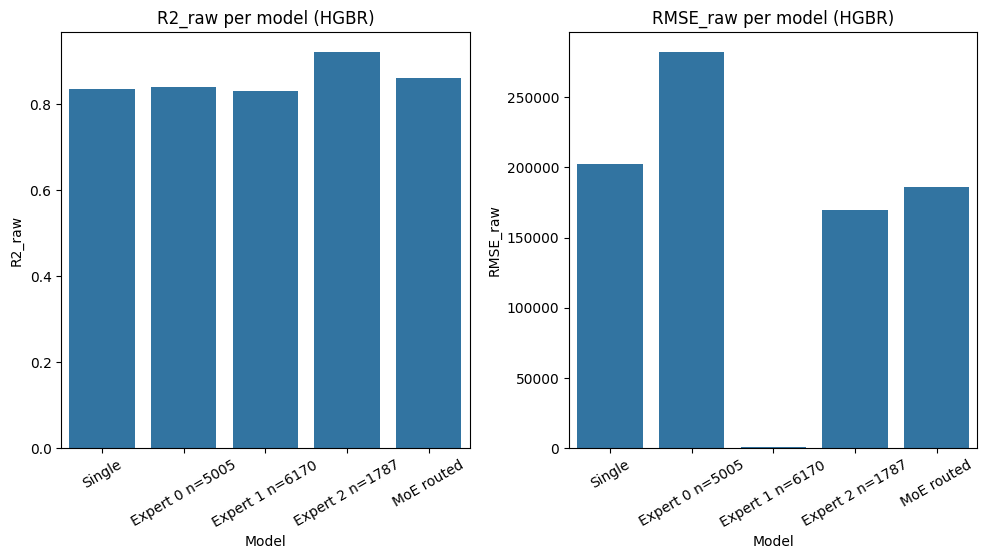

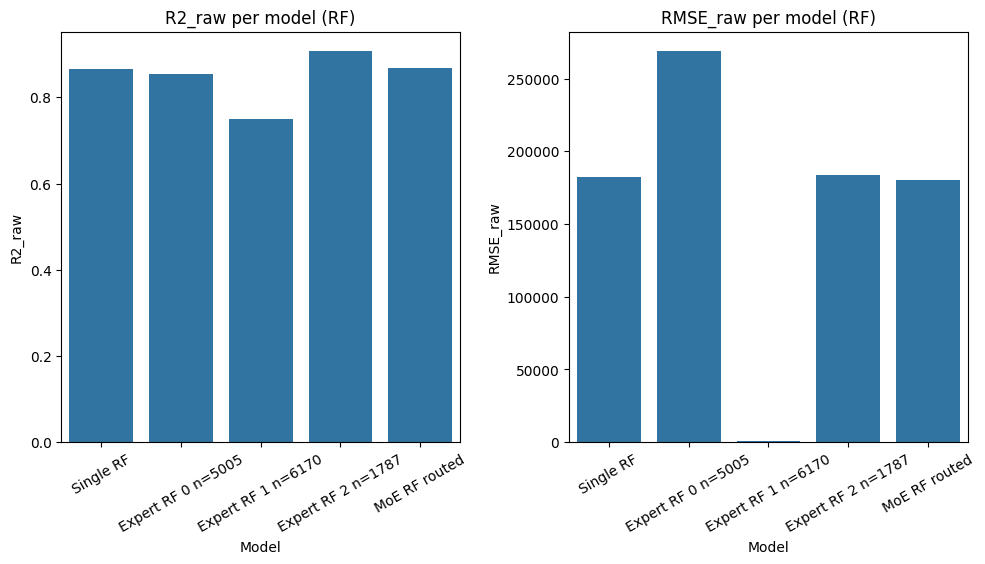

In [46]:
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
sns.barplot(data=df_metrics.iloc[:5], x="Model", y="R2_raw")
plt.title("R2_raw per model (HGBR)")
plt.xticks(rotation=30)
plt.subplot(2,2,2)
sns.barplot(data=df_metrics.iloc[:5], x="Model", y="RMSE_raw")
plt.title("RMSE_raw per model (HGBR)")
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

plt.figure(figsize=(10,10))
plt.subplot(2,2,3)
sns.barplot(data=df_metrics_rf.iloc[:5], x="Model", y="R2_raw")
plt.title("R2_raw per model (RF)")
plt.xticks(rotation=30)
plt.subplot(2,2,4)
sns.barplot(data=df_metrics_rf.iloc[:5], x="Model", y="RMSE_raw")
plt.title("RMSE_raw per model (RF)")
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

Single (HGBR) top 5
logpost_images               0.200765
reach_time_bucket_normal     0.080012
loguser_median_engagement    0.060754
logfollowers                 0.000000
carousel_1                   0.000000


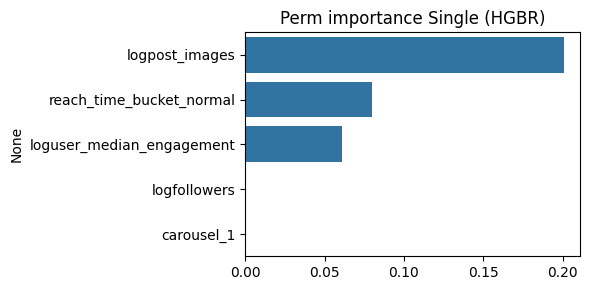

Expert 0 (HGBR) top 5
loguser_median_engagement    0.780136
logfollowers                 0.214977
logpost_images               0.041692
loguser_post_count           0.035056
video_1                      0.008478


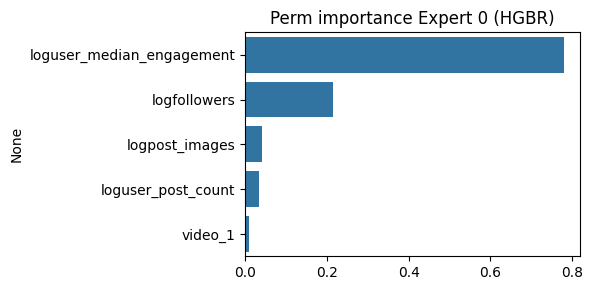

Expert 1 (HGBR) top 5
logfollowers                 1.488643
loguser_median_engagement    0.014248
loglength_caption            0.009969
logpost_images               0.005446
loguser_post_count           0.003351


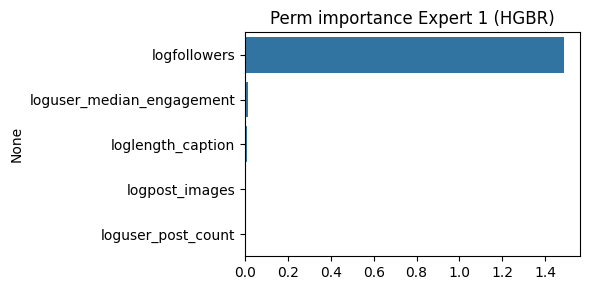

Expert 2 (HGBR) top 5
loguser_median_engagement    1.442798
logfollowers                 0.046665
logpost_images               0.020430
loglength_caption            0.008010
video_1                      0.004763


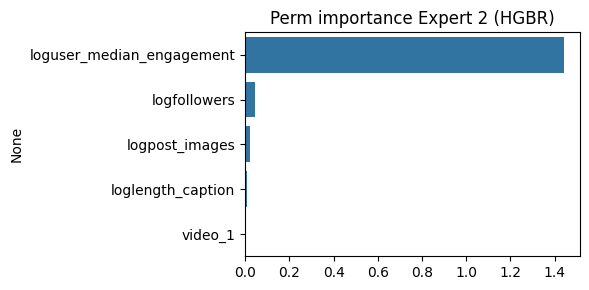

Single RF top 5
loguser_median_engagement    1.442798
logfollowers                 0.046665
logpost_images               0.020430
loglength_caption            0.008010
video_1                      0.004763


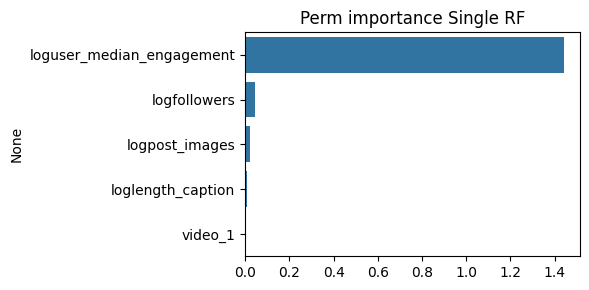

Expert RF 0 top 5
loguser_median_engagement    1.442798
logfollowers                 0.046665
logpost_images               0.020430
loglength_caption            0.008010
video_1                      0.004763


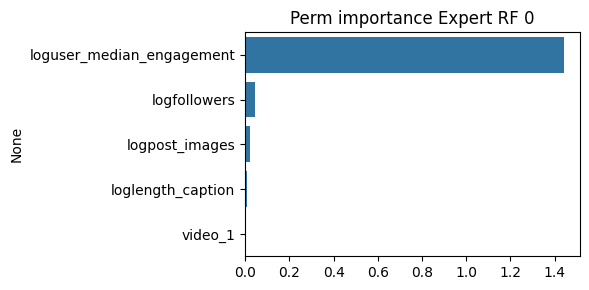

Expert RF 1 top 5
loguser_median_engagement    1.442798
logfollowers                 0.046665
logpost_images               0.020430
loglength_caption            0.008010
video_1                      0.004763


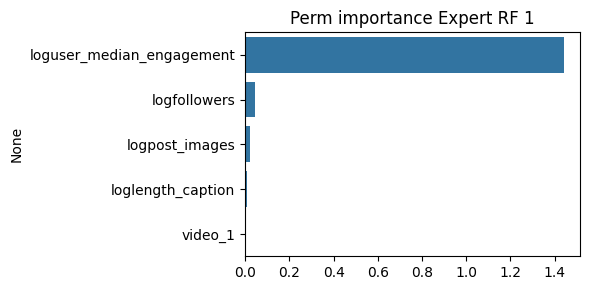

Expert RF 2 top 5
loguser_median_engagement    1.442798
logfollowers                 0.046665
logpost_images               0.020430
loglength_caption            0.008010
video_1                      0.004763


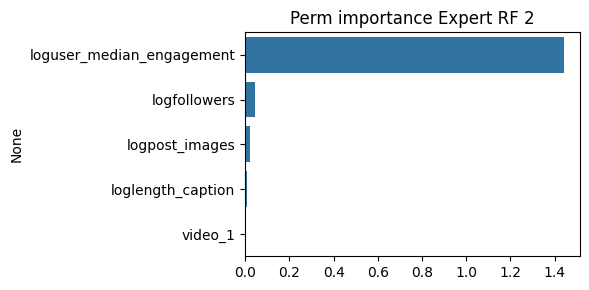

In [47]:
for name, model, X, y in [("Single (HGBR)", single, X_test, y_test_raw), ("Expert 0 (HGBR)", experts[0], X_test[test_cluster==0], y_test_raw[test_cluster==0])
,("Expert 1 (HGBR)", experts[1], X_test[test_cluster==1], y_test_raw[test_cluster==1]),("Expert 2 (HGBR)", experts[2], X_test[test_cluster==2], y_test_raw[test_cluster==2])]:
    perm = permutation_importance(model, X, y, n_repeats=5, random_state=42, scoring='r2')
    imp=pd.Series(perm.importances_mean, index=X_train.columns).sort_values(ascending=False)
    print(f"{name} top 5")
    print(imp.head(5).to_string())
    plt.figure(figsize=(6,3))
    sns.barplot(x=imp.head(5).values, y=imp.head(5).index)
    plt.title(f"Perm importance {name}")
    plt.tight_layout(); plt.show()

for name, model, X, y in [("Single RF", single2, X_test, y_test_raw),
                           ("Expert RF 0", experts_rf[0], X_test[test_cluster==0], y_test_raw[test_cluster==0]),
                           ("Expert RF 1", experts_rf[1], X_test[test_cluster==1], y_test_raw[test_cluster==1]),
                           ("Expert RF 2", experts_rf[2], X_test[test_cluster==2], y_test_raw[test_cluster==2])]:
    perm_rf = permutation_importance(model, X, y, n_repeats=5, random_state=42, scoring='r2', n_jobs=-1)
    imp = pd.Series(perm.importances_mean, index=X_train.columns).sort_values(ascending=False)
    print(f"{name} top 5")
    print(imp.head(5).to_string())
    plt.figure(figsize=(6,3))
    sns.barplot(x=imp.head(5).values, y=imp.head(5).index)
    plt.title(f"Perm importance {name}")
    plt.tight_layout(); plt.show()

In [48]:
experts_mixed = {}
for c in range(3):
    mask = train_cluster == c
    Xc = X_train[mask]
    yc = y_train_raw[mask]
    print(f"cluster {c} n={mask.sum()} mean_raw {yc.mean():.0f} median {yc.median():.0f}")

    if c == 0:
        m = RandomForestRegressor(n_estimators=300, max_depth=8 if mask.sum() > 1000 else 6,
                                   random_state=42, n_jobs=-1)
    else:
        m = HistGradientBoostingRegressor(max_depth=8 if mask.sum() > 1000 else 6,
                                           learning_rate=0.08, max_iter=300, random_state=42)
    m.fit(Xc, yc)
    experts_mixed[c] = m
    print(f" cluster {c} ({m.__class__.__name__}) train R2 {r2_score(yc, m.predict(Xc)):.4f}")

pred_raw_routed_mixed = np.zeros(len(X_test))
for c in range(3):
    mask = test_cluster == c
    if mask.sum() > 0:
        pred_raw_routed_mixed[mask] = experts_mixed[c].predict(X_test[mask])

print(f"MoE-mixed ROUTED test real R2 {r2_score(y_test_raw, pred_raw_routed_mixed):.4f} "
      f"RMSE {np.sqrt(mean_squared_error(y_test_raw, pred_raw_routed_mixed)):.0f} "
      f"MAE {mean_absolute_error(y_test_raw, pred_raw_routed_mixed):.0f}")

for c in range(3):
    mask = test_cluster == c
    print(f" cluster {c} test n={mask.sum()} "
          f"R2_raw {r2_score(y_test_raw[mask], pred_raw_routed_mixed[mask]):.4f} "
          f"RMSE {np.sqrt(mean_squared_error(y_test_raw[mask], pred_raw_routed_mixed[mask])):.0f}")

cluster 0 n=20067 mean_raw 167425 median 7480
 cluster 0 (RandomForestRegressor) train R2 0.9089
cluster 1 n=24604 mean_raw 411 median 242
 cluster 1 (HistGradientBoostingRegressor) train R2 0.6327
cluster 2 n=7177 mean_raw 72729 median 1159
 cluster 2 (HistGradientBoostingRegressor) train R2 0.9728
MoE-mixed ROUTED test real R2 0.8719 RMSE 178524 MAE 30627
 cluster 0 test n=5005 R2_raw 0.8543 RMSE 268870
 cluster 1 test n=6170 R2_raw 0.8309 RMSE 492
 cluster 2 test n=1787 R2_raw 0.9212 RMSE 169421


In [49]:
rows_mixed = []
def add_row_mixed(name, y_raw_true, y_raw_pred):
    rows_mixed.append([name, r2_score(y_raw_true, y_raw_pred),
                        mean_squared_error(y_raw_true, y_raw_pred),
                        np.sqrt(mean_squared_error(y_raw_true, y_raw_pred)),
                        mean_absolute_error(y_raw_true, y_raw_pred)])

add_row_mixed("Single RF", y_test_raw, pred_single2)

for c in range(3):
    mask = test_cluster == c
    add_row_mixed(f"Expert Mixed {c} n={mask.sum()}", y_test_raw[mask], pred_raw_routed_mixed[mask])

add_row_mixed("MoE Mixed routed", y_test_raw, pred_raw_routed_mixed)

df_metrics_mixed = pd.DataFrame(rows_mixed, columns=["Model", "R2_raw", "MSE_raw", "RMSE_raw", "MAE_raw"])
print(df_metrics_mixed.to_string(index=False))

                Model   R2_raw      MSE_raw      RMSE_raw      MAE_raw
            Single RF 0.866252 3.327241e+10 182407.257809 30391.173088
Expert Mixed 0 n=5005 0.854260 7.229102e+10 268869.891971 68279.425199
Expert Mixed 1 n=6170 0.830890 2.425055e+05    492.448476   252.942133
Expert Mixed 2 n=1787 0.921166 2.870335e+10 169420.634853 30043.667129
     MoE Mixed routed 0.871886 3.187093e+10 178524.299082 30627.002719
